## Tearing instability in 2D RMHD

The **tearing mode** is the classic resistive instability of a current sheet, and the
standard validation problem for reduced-MHD codes. In ideal MHD a sheared magnetic field
cannot change its topology, but a small resistivity $\eta$ lets field lines break and
reconnect at *resonant surfaces* where $\mathbf{k}\cdot\mathbf{B}=0$. The sheet then
"tears" into a chain of **magnetic islands** separated by X-points, growing exponentially
at a rate set by a hybrid of the (slow) resistive time and the (fast) Alfven time.

We build the equilibrium from the flux function

$$\psi_{eq} = \cos(x) \qquad\Rightarrow\qquad \mathbf{b}_\perp = \hat{z}\times\nabla_\perp\psi = -\sin(x)\,\hat{y},$$

so $B_y$ reverses sign at $x=0$ and $x=\pi$ (the resonant surfaces), and perturb it with
$\delta\psi = \epsilon\cos(k y)$, $k=1/2$, which is resonant there
($\mathbf{k}\cdot\mathbf{B} = k B_y = 0$).

**Linear theory.** The boundary-layer analysis of Furth, Killeen & Rosenbluth (1963)
reduces the outer (ideal) region to a jump condition across the thin resistive layer,
measured by the tearing stability index $\Delta' = [\psi'/\psi]_{x_s^-}^{x_s^+}$. The mode
is unstable when $\Delta' > 0$ -- for this equilibrium, when $k<1$ -- and there are two
asymptotic regimes:

- **small $\Delta'$ (FKR, "constant-$\psi$"):** $\;\gamma \propto \eta^{3/5}\,\Delta'^{4/5}$
- **large $\Delta'$ (Coppi et al.):** $\;\gamma \propto \eta^{1/3}$

At $k=1/2$ this equilibrium has $\Delta'$ of order unity, and at the moderate
resistivities a laptop run can afford the resistive layer is not asymptotically thin, so
the measured slope of $\gamma(\eta)$ typically lands **between** $1/3$ and $3/5$. That is
exactly what we will find below.

Because the whole point is the scaling with *real* resistivity, these runs use a true
Laplacian dissipation operator (`hyper=1`) -- hyperdissipation would concentrate at the
grid scale and destroy the $\gamma(\eta)$ law. Viscosity equals resistivity (magnetic
Prandtl number $Pm=1$).

At much higher Lundquist number ($S = \eta^{-1} \gtrsim 10^4$ in these units) the
reconnecting current sheet itself goes unstable and breaks into a chain of **plasmoids**;
that regime needs far more resolution than we use here (see the exercises).

In [1]:
#imports -- same pattern as orzag-tang-2D.ipynb
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt

#snapshot reading/writing utilities
import jax_rmhd.snapshot_io as sn

jax is using 64bit precision.


### Setup

All runs share one grid: $128\times256$ on $L_x=2\pi$, $L_y=4\pi$, so the $m=1$ mode in
$y$ has exactly $k = 2\pi/L_y = 1/2$. Only the resistivity $\eta$ (and with it the
viscosity, $Pm=1$) changes between runs. Each run writes snapshots into its own directory
under `data/tearing-mode-2D/`; if a completed run is already on disk it is reused, so
re-running the notebook costs nothing.

One caveat to keep in mind: nothing holds the equilibrium up against resistive diffusion,
so $\psi_{eq}=\cos x$ itself decays as $e^{-\eta t}$ (it is a $k_\perp^2=1$ mode of the
pure diffusion equation). The instantaneous growth rate therefore drifts slowly downward
over a run. We handle this by fitting $\ln A(t)$ over an **early** amplitude window --
after the initial transient, but long before saturation.

In [2]:
#shared numerical setup for every run in this notebook
nx = 128
ny = 256
Lx = 2.0 * jnp.pi
Ly = 4.0 * jnp.pi     #the m=1 mode in y has k = 2*pi/Ly = 0.5
hyper = 1             #TRUE Laplacian dissipation -- essential here: the gamma(eta)
                      #scaling is a statement about real resistivity
cfl_safety = 0.5
eps = 1e-4            #perturbation amplitude: small enough for a long linear phase
kpert = 0.5           #k_y of the seeded island mode

def tearing_init(x, y):
    #equilibrium flux function psi_eq = cos(x): with b_perp = hz x grad_perp(psi),
    #this gives B_y(x) = -sin(x), reversing at the resonant surfaces x = 0 and pi.
    #delta_psi = eps*cos(kpert*y) seeds the island chain; phi = 0 starts at rest.
    psi = jnp.cos(x) + eps * jnp.cos(kpert * y)
    phi = jnp.zeros_like(psi)
    return jnp.stack([phi, psi], axis=0)

def run_tearing(eta, t_end, t_snap):
    #one tearing run at resistivity (= viscosity, Pm=1) eta.
    #Each run gets its own snapshot directory; if that directory already holds a
    #completed run we simply reuse it instead of rerunning.
    snap_path = f"data/tearing-mode-2D/eta_{eta:.0e}/".replace("e-0", "e-")
    params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, diss=(eta, eta),
                          hyper=hyper, cfl_safety=cfl_safety, dims=2)
    #record the constructor arguments into the run directory (good practice: the
    #directory then documents how it was made, and Parameters.from_snapshot can
    #rebuild the exact same Parameters later)
    params.save(snap_path)
    kgrid = jr.setup_kgrids(params)
    #reuse a finished run if one is already on disk
    steps = sn.get_saved_steps(snap_path)
    if steps and float(sn.load_snapshot(steps[-1], snap_path, params).t) >= t_end:
        print(f"eta={eta:g}: reusing completed run in {snap_path}")
        return params, kgrid, snap_path
    mngr = jr.snapshot_manager_setup(params, snap_path=snap_path, nsnap=1000)
    state = jr.initialize(tearing_init, params)
    nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
    #buffer donation: simulate_scan CONSUMES `state` -- never touch it again
    #afterwards; everything below post-processes the saved snapshots instead.
    jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap, t_end=t_end,
                     mngr=mngr, save=True, print_every=50)
    return params, kgrid, snap_path

def island_amplitude(snap_path, params):
    #A(t) = |psi_k| at the seeded island mode: fields[1] is psi, z-index 0 (2D),
    #kx index 0, ky index 1 (i.e. k_y = 2*pi/Ly = 0.5)
    ts, As = [], []
    for isnap in sn.get_saved_steps(snap_path):
        snap = sn.load_snapshot(isnap, snap_path, params)
        ts.append(float(snap.t))
        As.append(float(jnp.abs(snap.fields[1][0, 0, 1])))
    return np.array(ts), np.array(As)

def fit_gamma(ts, As, band=(5.0, 500.0)):
    #fit ln A(t) over an EARLY amplitude window: above band[0]*A0 (skips the
    #initial transient while the perturbation relaxes onto the tearing
    #eigenfunction) and below band[1]*A0 (well before saturation, and early
    #enough that the slow resistive decay of the equilibrium has not dragged
    #gamma down much -- see the caveat above)
    A0 = As[0]
    i0 = int(np.argmax(As >= band[0] * A0))
    above = np.nonzero(As >= band[1] * A0)[0]
    i1 = int(above[0]) if len(above) else len(As)
    gamma, lnC = np.polyfit(ts[i0:i1], np.log(As[i0:i1]), 1)
    return gamma, lnC, (ts[i0], ts[i1 - 1])

### Featured run: $\eta = 10^{-3}$

Run one case with fairly frequent snapshots so we can watch the island grow. This takes
a few minutes on a laptop (the growth rate is small, so we must run to $t\sim450$, i.e.
tens of thousands of timesteps).

In [3]:
eta_feat = 1e-3
params_f, kgrid_f, path_f = run_tearing(eta_feat, t_end=450.0, t_snap=2.0)

Saving initial state as snapshot 0
Saving snapshot 1
Saving snapshot 2
Saving snapshot 3
Saving snapshot 4
Saving snapshot 5
Saving snapshot 6
Saving snapshot 7
Saving snapshot 8
Saving snapshot 9
Saving snapshot 10
Saving snapshot 11
Saving snapshot 12
Saving snapshot 13
Saving snapshot 14
Saving snapshot 15
Saving snapshot 16
Saving snapshot 17
Saving snapshot 18
Saving snapshot 19
Saving snapshot 20
Saving snapshot 21
Saving snapshot 22
Saving snapshot 23
Saving snapshot 24
Saving snapshot 25
Saving snapshot 26
Saving snapshot 27
Saving snapshot 28
Saving snapshot 29
Saving snapshot 30
Saving snapshot 31
Saving snapshot 32
Saving snapshot 33
Saving snapshot 34
Saving snapshot 35
Saving snapshot 36
Saving snapshot 37
Saving snapshot 38
Saving snapshot 39
Saving snapshot 40
Saving snapshot 41
Saving snapshot 42
Saving snapshot 43
Saving snapshot 44
Saving snapshot 45
Saving snapshot 46
Saving snapshot 47
104.69482748337552
Saving snapshot 48
Saving snapshot 49
Saving snapshot 50
Savin

### Current density: watching the sheet tear

The (z-directed) current density is $j = -\nabla_\perp^2\psi$, which in k-space is simply
`ksq * psi_k`. Early on it is the smooth $j = \cos x$ of the equilibrium; by the end of
the linear phase, a localized current spike (the reconnecting X-point) and a growing
island (closed loops in the overlaid field-line contours of $\psi$) have formed at each
resonant surface.

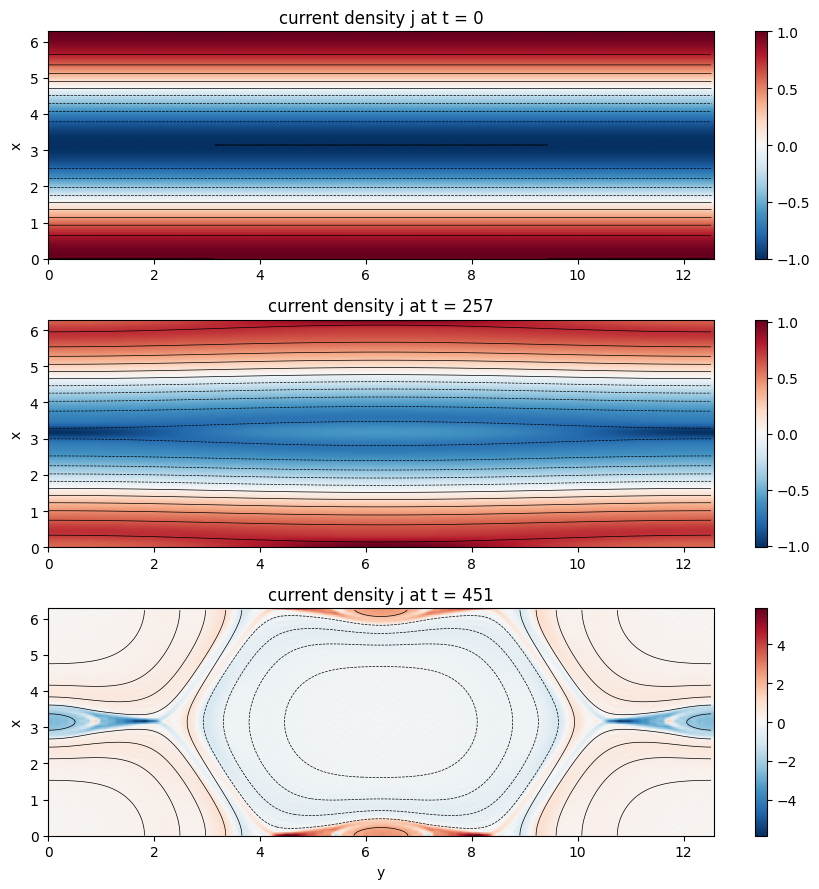

In [4]:
ts_f, As_f = island_amplitude(path_f, params_f)
steps_f = sn.get_saved_steps(path_f)

#three moments: the start, the late linear phase (A ~ 300 A0), and the end
picks = [0, int(np.argmax(As_f >= 300.0 * As_f[0])), len(steps_f) - 1]

x = np.linspace(0, float(Lx), nx, endpoint=False)
y = np.linspace(0, float(Ly), ny, endpoint=False)
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, i in zip(axes, picks):
    snap = sn.load_snapshot(steps_f[i], path_f, params_f)
    j = np.asarray(ft.irfft2(kgrid_f.ksq * snap.fields[1, 0]))   #j = -grad_perp^2 psi
    psi = np.asarray(ft.irfft2(snap.fields[1, 0]))
    im = ax.imshow(j, origin="lower", extent=(0, float(Ly), 0, float(Lx)),
                   cmap="RdBu_r", aspect="auto")
    #contours of psi are the in-plane field lines: islands appear as closed loops
    ax.contour(y, x, psi, levels=12, colors="k", linewidths=0.5)
    ax.set_title(f"current density j at t = {float(snap.t):.0f}")
    ax.set_ylabel("x")
    fig.colorbar(im, ax=ax)
axes[-1].set_xlabel("y")
plt.tight_layout()

### Island amplitude and growth rate

The cleanest scalar measure of the island is the amplitude of the seeded Fourier mode
itself, $A(t) = |\hat\psi(k_x{=}0,\,k_y{=}1/2)|$, read straight out of each snapshot.
On a semilog plot the linear phase is a straight line; a fit over the early amplitude
band gives $\gamma$. Note the departure from pure exponential growth at late times: first
the slow downward drift as the equilibrium resistively decays, then genuine nonlinear
saturation once the island width becomes comparable to the resistive layer width
(Rutherford's algebraic regime and, eventually, a saturated island).

fitted gamma = 0.0188 over t in [41, 283]


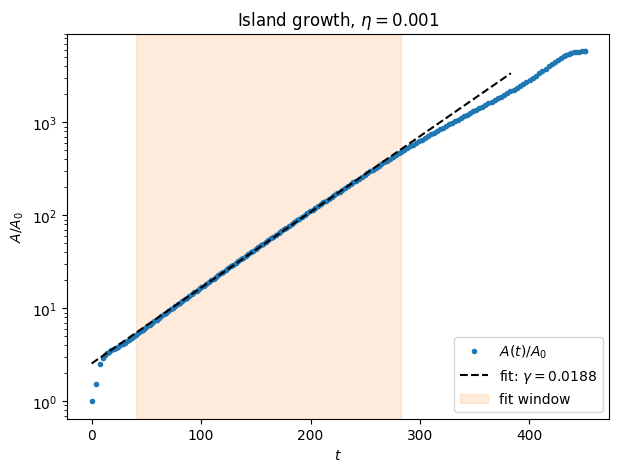

In [5]:
gamma_f, lnC_f, (tfit0, tfit1) = fit_gamma(ts_f, As_f)
A0 = As_f[0]

plt.figure(figsize=(7, 5))
plt.semilogy(ts_f, As_f / A0, "o", ms=3, label=r"$A(t)/A_0$")
tt = np.linspace(0.0, min(tfit1 + 100.0, ts_f[-1]), 200)
plt.semilogy(tt, np.exp(gamma_f * tt + lnC_f) / A0, "k--",
             label=rf"fit: $\gamma = {gamma_f:.4f}$")
plt.axvspan(tfit0, tfit1, alpha=0.15, color="C1", label="fit window")
plt.xlabel(r"$t$")
plt.ylabel(r"$A/A_0$")
plt.legend()
plt.title(rf"Island growth, $\eta = {eta_feat:g}$")
print(f"fitted gamma = {gamma_f:.4f} over t in [{tfit0:.0f}, {tfit1:.0f}]")

### Growth rate vs resistivity

Now the actual physics result: repeat the run at several resistivities and measure the
scaling $\gamma(\eta)$. Slower-growing (smaller $\eta$) cases need longer runs to get
through the transient and the fit window, so each case has its own `t_end`. The
$\eta=10^{-3}$ case reuses the featured run's snapshots from disk instead of rerunning.

In [6]:
etas = [5e-4, 1e-3, 2e-3, 4e-3]
t_ends = {5e-4: 650.0, 1e-3: 450.0, 2e-3: 350.0, 4e-3: 250.0}

gammas = {}
for eta in etas:
    params_e, kgrid_e, path_e = run_tearing(eta, t_end=t_ends[eta], t_snap=5.0)
    ts_e, As_e = island_amplitude(path_e, params_e)
    g, _, win = fit_gamma(ts_e, As_e)
    gammas[eta] = g
    print(f"eta = {eta:7.1e}   gamma = {g:.4f}   (fit window t = [{win[0]:.0f}, {win[1]:.0f}])")

Saving initial state as snapshot 0
Saving snapshot 1
Saving snapshot 2
Saving snapshot 3
Saving snapshot 4
Saving snapshot 5
Saving snapshot 6
Saving snapshot 7
Saving snapshot 8
Saving snapshot 9
Saving snapshot 10
Saving snapshot 11
Saving snapshot 12
Saving snapshot 13
Saving snapshot 14
Saving snapshot 15
Saving snapshot 16
Saving snapshot 17
Saving snapshot 18
Saving snapshot 19
Saving snapshot 20
Saving snapshot 21
Saving snapshot 22
Saving snapshot 23
Saving snapshot 24
Saving snapshot 25
Saving snapshot 26
Saving snapshot 27
Saving snapshot 28
Saving snapshot 29
Saving snapshot 30
Saving snapshot 31
Saving snapshot 32
Saving snapshot 33
Saving snapshot 34
Saving snapshot 35
Saving snapshot 36
Saving snapshot 37
Saving snapshot 38
Saving snapshot 39
Saving snapshot 40
Saving snapshot 41
Saving snapshot 42
Saving snapshot 43
Saving snapshot 44
Saving snapshot 45
Saving snapshot 46
Saving snapshot 47
Saving snapshot 48
266.054223957145
Saving snapshot 49
Saving snapshot 50
Saving 

fitted power-law index: gamma ~ eta^0.45   (FKR: 0.6, Coppi: 0.33)


Text(0.5, 1.0, 'Tearing growth rate vs resistivity')

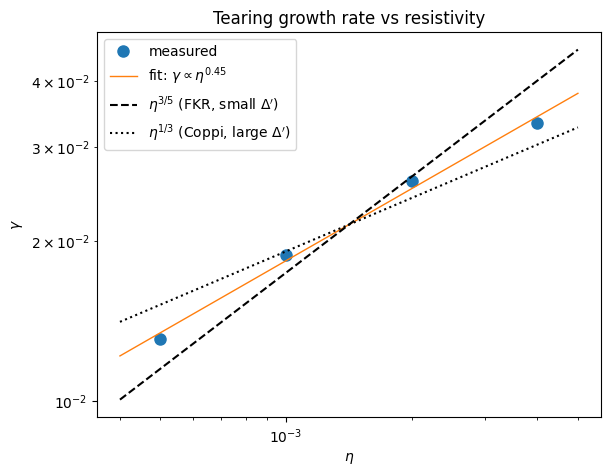

In [7]:
eta_arr = np.array(etas)
g_arr = np.array([gammas[e] for e in etas])

#power-law index from a straight-line fit in log-log
p = np.polyfit(np.log(eta_arr), np.log(g_arr), 1)
print(f"fitted power-law index: gamma ~ eta^{p[0]:.2f}   (FKR: 0.6, Coppi: 0.33)")

plt.figure(figsize=(6.5, 5))
plt.loglog(eta_arr, g_arr, "o", ms=8, label="measured")
#reference slopes anchored at the geometric middle of the fit
eta_ref = np.sqrt(eta_arr[0] * eta_arr[-1])
g_ref = np.exp(np.polyval(p, np.log(eta_ref)))
ee = np.geomspace(eta_arr[0] * 0.8, eta_arr[-1] * 1.25, 50)
plt.loglog(ee, np.exp(np.polyval(p, np.log(ee))), "C1-", lw=1,
           label=rf"fit: $\gamma\propto\eta^{{{p[0]:.2f}}}$")
plt.loglog(ee, g_ref * (ee / eta_ref) ** (3.0 / 5.0), "k--",
           label=r"$\eta^{3/5}$ (FKR, small $\Delta'$)")
plt.loglog(ee, g_ref * (ee / eta_ref) ** (1.0 / 3.0), "k:",
           label=r"$\eta^{1/3}$ (Coppi, large $\Delta'$)")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
plt.legend()
plt.title("Tearing growth rate vs resistivity")

### Discussion

The overall index lands between the two asymptotic predictions, and for a good physical
reason: the regimes are set by the size of $\Delta'\delta$, where
$\delta \sim (\gamma/\eta)^{-1/2}\,$ (in the layer scalings, $\delta\propto\eta^{2/5}$
for FKR) is the resistive layer width. Since $\delta$ shrinks as $\eta$ decreases, a mode
with fixed $\Delta'\sim O(1)$ slides from the large-$\Delta'$ (Coppi, slope $1/3$) end at
our largest resistivities toward the constant-$\psi$ FKR end (slope $3/5$) at the
smallest. Look at the *local* slope between adjacent points of the scan: it flattens
toward $1/3$ at large $\eta$ and steepens toward $3/5$ at small $\eta$, exactly this
crossover. Reaching a clean asymptotic FKR scaling would need substantially smaller
$\eta$ -- and with it more resolution to resolve the ever-thinner layer.

(Resolution check: rerunning the smallest-resistivity case, $\eta=5\times10^{-4}$, on a
doubled $256\times512$ grid changes the fitted $\gamma$ by only ~0.2% (0.0131 on both grids), so
the $128\times256$ grid is adequate across this scan.)

### Things to try

- **Q1 -- stability boundary:** this equilibrium is tearing-unstable only for $k<1$.
  Seed the $m=2$ mode ($k=1$, `eps*jnp.cos(1.0*y)`) instead and verify it refuses to
  grow; or double `Ly` and seed $k=1/4$, which has larger $\Delta'$ -- does $\gamma$
  increase?
- **Q2 -- island width:** from the saturated snapshots, estimate the island full width
  $W = 4\sqrt{A/|\psi_{eq}''(x_s)|}$ and compare it with what you see in the field-line
  contours.
- **Q3 -- Prandtl number:** repeat the scan with `diss=(visc, res)` unequal ($Pm = 0.1$
  and $10$). How sensitive is $\gamma$ to viscosity in each regime?
- **Q4 -- negative control:** rerun one case with `hyper=2` at a dissipation coefficient
  chosen to give a similar grid-scale damping. The island still grows -- but the
  $\gamma(\eta)$ law is destroyed. This is why `hyper=1` matters here.
- **Q5 -- plasmoid instability (expensive):** at $S=\eta^{-1}\gtrsim10^4$ the secondary
  current sheet that forms at the X-point during nonlinear island growth is itself
  tearing-unstable and breaks into a chain of plasmoids. Try $\eta\le10^{-4}$ at
  $512\times1024$ or better (ideally with `RMHD_PRECISION=64`) and watch the current
  density movie -- this is the gateway to fast reconnection, and a good excuse to move
  to a cluster.